# Otkrivanje tema u korpusu vesti pomoću NMF faktorizacije nad TF-IDF matricom sa bigramima

Redosled rada: TF-IDF matrica sa bigramima, zatim NMF u sopstvenoj implementaciji, pa teme,
evaluacija i semantička pretraga.

## 1. Podaci

`./bbc_dataset/bbc`: 2.225 BBC članaka u 5 foldera (business, entertainment, politics, sport,
tech). Preuzima se Kaggle API-jem, traži `kaggle.json` u `~/.kaggle/`.

In [1]:
%pip install --quiet kaggle matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

download_path = "./bbc_dataset"
dataset_path = os.path.join(download_path, "bbc")

if os.path.isdir(dataset_path) and os.listdir(dataset_path):
    print(f"Podaci već postoje u '{dataset_path}'")
else:

    api = KaggleApi()
    api.authenticate()

    dataset = "shivamkushwaha/bbc-full-text-document-classification"
    os.makedirs(download_path, exist_ok=True)
    api.dataset_download_files(dataset, path=download_path, unzip=False)

    zip_files = [f for f in os.listdir(download_path) if f.endswith(".zip")]
    if zip_files:
        zip_path = os.path.join(download_path, zip_files[0])
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(download_path)
        os.remove(zip_path)
        print(f"Uspešno završeno!")
    else:
        raise RuntimeError("Fajl nije pronađen")

Podaci već postoje u './bbc_dataset\bbc'


## 2. Istraživačka analiza

`broj_po_kategoriji` i `duzine_po_kategoriji`: koliko ima dokumenata i koliko su dugački, po
kategoriji.

In [3]:
import numpy as np

dataset_path = "./bbc_dataset/bbc"


kategorije_lista = []
for d in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, d)):
        kategorije_lista.append(d)

kategorije_lista = sorted(kategorije_lista)

broj_po_kategoriji = {}
duzine_po_kategoriji = {}

for kat in kategorije_lista:
    cat_path = os.path.join(dataset_path, kat)
    fajlovi = sorted(os.listdir(cat_path))
    broj_po_kategoriji[kat] = len(fajlovi)
    duzine = []
    for fajl in fajlovi:
        with open(os.path.join(cat_path, fajl), "r", encoding="utf-8", errors="ignore") as f:
            duzine.append(len(f.read().split()))
    duzine_po_kategoriji[kat] = np.array(duzine)

ukupno = sum(broj_po_kategoriji.values())
sve_duzine = np.concatenate(list(duzine_po_kategoriji.values()))

print(f"{'kategorija':<15} {'dokumenata':>11} {'udeo':>8} {'med. dužina':>13}")
print("-" * 50)
for kat in kategorije_lista:
    d = duzine_po_kategoriji[kat]
    print(f"{kat:<15} {broj_po_kategoriji[kat]:>11} {broj_po_kategoriji[kat]/ukupno:>7.1%} "
          f"{int(np.median(d)):>13}")
print("-" * 50)
print(f"{'UKUPNO':<15} {ukupno:>11} {1.0:>7.1%} {int(np.median(sve_duzine)):>13}")
print(f"\nDužina dokumenta (reči): min {sve_duzine.min()}, medijana "
      f"{int(np.median(sve_duzine))}, maks {sve_duzine.max()}")

kategorija       dokumenata     udeo   med. dužina
--------------------------------------------------
business                510   22.9%           297
entertainment           386   17.3%           262
politics                417   18.7%           439
sport                   511   23.0%           288
tech                    401   18.0%           447
--------------------------------------------------
UKUPNO                 2225  100.0%           332

Dužina dokumenta (reči): min 89, medijana 332, maks 4432


Skup je izbalansiran, po kategoriji ima između 386 i 511 dokumenata. Nasumično pogađanje daje
20%.

## 3. Tokenizacija

`tokenizuj(tekst)`: spušta na mala slova, izbacuje interpunkciju, brojeve, stop-reči i tokene kraće
od 3 slova, pa od susednih sadržajnih reči pravi bigrame (`prime minister`, `bank of england`).

In [4]:
import re

STOP_RECI = set('''
a about above after again against all am an and any are aren't as at be because been before being
below between both but by can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her
here here's hers herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's
its itself let's me more most mustn't my myself no nor not of off on once only or other ought our
ours ourselves out over own same shan't she she'd she'll she's should shouldn't so some such than
that that's the their theirs them themselves then there there's these they they'd they'll they're
they've this those through to too under until up very was wasn't we we'd we'll we're we've were
weren't what what's when when's where where's which while who who's whom why why's with won't would
wouldn't you you'd you'll you're you've your yours yourself yourselves
also would could said say says one two three mr mrs ms new like get got will
'''.split())

REC_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)*'?")


SPOJ_RE = re.compile(r"[ \t\-]*")

MIN_DUZINA_RECI = 3


def normalizuj(rec):
    rec = rec.lower()
    if rec.endswith("'s"):
        rec = rec[:-2]
    return rec.rstrip("'")


def je_sadrzajna(rec, akronim):
    if akronim:                       # US, UK, EU, TV
        return True
    if len(rec) < MIN_DUZINA_RECI:
        return False
    if rec in STOP_RECI:
        return False
    return True


def fraze_iz_niza(niz, akronimi, tokeni):
    n = len(niz)

    sadrzajna = []
    for i in range(n):
        sadrzajna.append(je_sadrzajna(niz[i], akronimi[i]))

    for i in range(n):
        if not sadrzajna[i]:
            continue

        tokeni.append(niz[i])                                        # unigram

        if i + 1 < n and sadrzajna[i + 1]:                           # bigram
            tokeni.append(niz[i] + " " + niz[i + 1])
        elif i + 2 < n and sadrzajna[i + 2]:                         # trigram sa rupom
            tokeni.append(niz[i] + " " + niz[i + 1] + " " + niz[i + 2])


def tokenizuj(tekst):
    tokeni = []
    niz = []
    akronimi = []
    kraj_prethodne = 0

    for m in REC_RE.finditer(tekst):
        izmedju = tekst[kraj_prethodne:m.start()] # za tacke da uhvati

        if niz and not SPOJ_RE.fullmatch(izmedju):  
            fraze_iz_niza(niz, akronimi, tokeni)      # ima nesto u nizu ali naleti na prekid poput tacke
            niz = []
            akronimi = []

        sirova = m.group()
        niz.append(normalizuj(sirova))
        akronimi.append(sirova.isupper() and len(sirova) >= 2)
        kraj_prethodne = m.end()

    if niz:
        fraze_iz_niza(niz, akronimi, tokeni)

    return tokeni


primeri = [
    "The Prime Minister said interest rates, and the US dollar, will rise in 2005!",
    "The Bank of England raised interest rates. Sales rose 4% last year.",
    "Shares in the state-owned firm fell. The company's profits were down.",
]

for p in primeri:
    print("ULAZ :", p)
    print("IZLAZ:", tokenizuj(p))
    print()


ULAZ : The Prime Minister said interest rates, and the US dollar, will rise in 2005!
IZLAZ: ['prime', 'prime minister', 'minister', 'minister said interest', 'interest', 'interest rates', 'rates', 'us', 'us dollar', 'dollar', 'rise']

ULAZ : The Bank of England raised interest rates. Sales rose 4% last year.
IZLAZ: ['bank', 'bank of england', 'england', 'england raised', 'raised', 'raised interest', 'interest', 'interest rates', 'rates', 'sales', 'sales rose', 'rose', 'last', 'last year', 'year']

ULAZ : Shares in the state-owned firm fell. The company's profits were down.
IZLAZ: ['shares', 'state', 'state owned', 'owned', 'owned firm', 'firm', 'firm fell', 'fell', 'company', 'company profits', 'profits']



`dokumenti`: lista tokena za svaki članak. `kategorije`: naziv foldera, koristi se tek u
evaluaciji, nikada u modelu.

In [5]:
import time

t0 = time.time()

putanje, kategorije, dokumenti = [], [], []
for kat in kategorije_lista:
    cat_path = os.path.join(dataset_path, kat)
    for fajl in sorted(os.listdir(cat_path)):
        p = os.path.join(cat_path, fajl)
        with open(p, "r", encoding="utf-8", errors="ignore") as f:
            dokumenti.append(tokenizuj(f.read()))
        putanje.append(p)
        kategorije.append(kat)



N = len(dokumenti)
print(f"Tokenizovano {N} dokumenata za {time.time() - t0:.1f} s")
print(f"Ukupan broj tokena u korpusu: {sum(len(d) for d in dokumenti):,}")
print(f"Prosečno tokena po dokumentu: {np.mean([len(d) for d in dokumenti]):.0f}")

Tokenizovano 2225 dokumenata za 5.8 s
Ukupan broj tokena u korpusu: 752,562
Prosečno tokena po dokumentu: 338


## 4. TF-IDF matrica

Neka je $N$ broj dokumenata, $\mathrm{tf}(t, d)$ broj pojavljivanja tokena $t$ u dokumentu $d$, a
$\mathrm{df}(t)$ broj dokumenata u kojima se $t$ javlja. Težina tokena je

$$\mathrm{idf}(t) = \ln\!\left(\frac{1 + N}{1 + \mathrm{df}(t)}\right) + 1,
\qquad V_{d,t} = \mathrm{tf}(t, d)\cdot \mathrm{idf}(t)$$

Jedinice u brojiocu i imeniocu sprečavaju deljenje nulom, a sabirak $1$ na kraju čuva od pada na
nulu tokene koji se javljaju u svakom dokumentu. Svaki red se na kraju normalizuje,

$$V_{d,:} \leftarrow \frac{V_{d,:}}{\|V_{d,:}\|_2}$$

pa dužina dokumenta ne utiče na njegovu težinu u faktorizaciji.

`df_broj`: u koliko se dokumenata javlja svaki token. Odatle se vidi i veličina sirovog rečnika.

In [6]:
from collections import Counter

t0 = time.time()
df_broj = Counter()
for tokeni in dokumenti:
    df_broj.update(set(tokeni))

sirovi_M = len(df_broj)
print(f"Sirovi rečnik (unigrami + fraze): {sirovi_M:,} tokena \n")
print(f"Gusta matrica V bi zauzela: {N * sirovi_M * 8 / 1e9:.2f} GB (float64)\n")

hapax = 0
for c in df_broj.values():
    if c == 1:
        hapax += 1

print(f"Tokena koji se javljaju u tačno 1 dokumentu: {hapax:,}  ({hapax / sirovi_M:.1%})")

Sirovi rečnik (unigrami + fraze): 227,793 tokena 

Gusta matrica V bi zauzela: 4.05 GB (float64)

Tokena koji se javljaju u tačno 1 dokumentu: 172,770  (75.8%)


`recnik`, `token_u_indeks` i `V`: rečnik posle pragova `MIN_DF = 5` i `MAX_DF = 0,5`, i L2
normalizovana TF-IDF matrica u CSR formatu (2.225 × 12.798, popunjenost 1,17%).

In [7]:
import math
from scipy.sparse import csr_matrix

MIN_DF = 5            # token mora biti >= 5 dokumenata
MAX_DF = 0.5          #  i u <= 50% dokumenata

t0 = time.time()

gornja_granica = MAX_DF * N

recnik = {}
for t,c in df_broj.items():
    if MIN_DF <= c <= gornja_granica:
        recnik[t] = c
recnik = sorted(recnik.keys())

M = len(recnik)

broj_unigrama = 0
for t in recnik:
    if " " not in t:
        broj_unigrama += 1  

print(f"Rečnik posle filtriranja: {M:,} tokena "
      f"({broj_unigrama:,} unigrama + {M - broj_unigrama:,} bigrama)")
print(f"Smanjenje u odnosu na sirovi rečnik: {sirovi_M / M:.1f}x\n")

#  IDF vektor

idf = np.zeros(M)
token_u_indeks = {}

for j, t in enumerate(recnik):
    token_u_indeks[t] = j
    df = df_broj[t]
    idf[j] = math.log((1 + N) / (1 + df)) + 1.0

redovi, kolone, vrednosti = [], [], []
for i, tokeni in enumerate(dokumenti):
    brojac = Counter()
    for t in tokeni:
        if t in token_u_indeks:
            brojac[t] += 1
            
    if not brojac:
        continue
    indeksi = []
    frekvencije = []
    for t, c in brojac.items():
        indeksi.append(token_u_indeks[t])
        frekvencije.append(c)

    idx = np.array(indeksi, dtype=np.int32)
    tf = np.array(frekvencije, dtype=np.float64)

    v = tf * idf[idx]                       # TF-IDF
    v = v / np.linalg.norm(v)                  # L2 normalizacija reda

    redovi.append(np.full(len(brojac), i, dtype=np.int32))
    kolone.append(idx)
    vrednosti.append(v)

V = csr_matrix(
    (np.concatenate(vrednosti), (np.concatenate(redovi), np.concatenate(kolone))),
    shape=(N, M),
)

#ISPISSSSS
gusto_gb = N * M * 8 / 1e9
retko_mb = (V.data.nbytes + V.indices.nbytes + V.indptr.nbytes) / 1e6
print(f"Matrica V: {V.shape[0]} x {V.shape[1]},  ne-nula elemenata: {V.nnz:,} "
      f"(popunjenost {V.nnz / (N * M):.2%})")
print(f"Memorija:  gusto {gusto_gb * 1000:.0f} MB   ->   retko {retko_mb:.1f} MB "
      f"({gusto_gb * 1000 / retko_mb:.0f}x manje)")
print(f"Vreme gradnje: {time.time() - t0:.1f} s")

Rečnik posle filtriranja: 12,798 tokena (8,946 unigrama + 3,852 bigrama)
Smanjenje u odnosu na sirovi rečnik: 17.8x



Matrica V: 2225 x 12798,  ne-nula elemenata: 332,850 (popunjenost 1.17%)
Memorija:  gusto 228 MB   ->   retko 4.0 MB (57x manje)
Vreme gradnje: 1.4 s


### 4.1 Provera

`maks_razlika`: najveće odstupanje od `sklearn`-ovog `TfidfVectorizer`-a nad istim rečnikom i istim
tokenima.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

kontrolni = TfidfVectorizer(analyzer=lambda d: d, vocabulary=token_u_indeks)
V_sklearn = kontrolni.fit_transform(dokumenti)

maks_razlika = abs(V - V_sklearn).max()
print(f"Maksimalna apsolutna razlika (naša implementacija vs sklearn): {maks_razlika:.2e}")

Maksimalna apsolutna razlika (naša implementacija vs sklearn): 5.55e-16


Razlika reda $10^{-16}$ je mašinska preciznost `float64`, znači obe implementacije daju istu
matricu.

## 5. NMF

Tražimo dve nenegativne matrice čiji proizvod najbolje aproksimira $V$:

$$\min_{W \ge 0,\; H \ge 0} \; \|V - WH\|_F^2, \qquad
V \in \mathbb{R}_+^{N \times M}, \quad
W \in \mathbb{R}_+^{N \times k}, \quad
H \in \mathbb{R}_+^{k \times M}$$

Problem nije konveksan po $W$ i $H$ istovremeno, ali jeste po svakoj matrici zasebno, pa se rešava
naizmeničnim ažuriranjem. Lee i Seung izvode multiplikativna pravila

$$H \leftarrow H \odot \frac{W^\top V}{W^\top W H}, \qquad
W \leftarrow W \odot \frac{V H^\top}{W H H^\top}$$

gde su $\odot$ i razlomak množenje i deljenje po koordinatama. Pravila ne povećavaju grešku u
svakom koraku, a nenegativnost se čuva sama od sebe jer se tekuće vrednosti množe nenegativnim
količnicima. Kvalitet merimo relativnom greškom rekonstrukcije

$$e = \frac{\|V - WH\|_F}{\|V\|_F}$$

Da se ne bi formirala gusta matrica $WH$ dimenzije $2225 \times 12798$, greška se računa preko

$$\|V - WH\|_F^2 = \|V\|_F^2 - 2\,\langle W,\, VH^\top \rangle + \langle W^\top W,\, HH^\top \rangle$$

gde je $\langle A, B \rangle = \sum_{i,j} A_{ij} B_{ij}$. Sva tri sabirka traže samo proizvod sa
retkom matricom i proizvode malih matrica reda $k$.

`nmf_mu(V, k)`: implementacija gornjih pravila. Vraća `W` (dokument × tema), `H` (tema × token) i
`istorija` (relativna greška po iteracijama).

In [9]:
def nmf_mu(V, k, max_iter=400, seed=0, tol=1e-6,
           eps=1e-10, meri_svakih=5, verbose=True):

    n, m = V.shape
    
    rng = np.random.default_rng(seed)
    skala = math.sqrt(V.mean() / k)
    W = np.abs(rng.normal(0, skala, (n, k))) + eps
    H = np.abs(rng.normal(0, skala, (k, m))) + eps

    norma_V = math.sqrt(V.multiply(V).sum() if hasattr(V, "multiply") else np.sum(V * V))
    istorija = []
    prethodna = None

    for it in range(1, max_iter + 1):
        # ažuriranje H:  H <- H * (W^T V) / (W^T W H)
        brojilac = np.asarray(W.T @ V)            
        imenilac = (W.T @ W) @ H                  
        H *= brojilac / (imenilac + eps)

        # ažuriranje W:  W <- W * (V H^T) / (W H H^T)
        brojilac = np.asarray(V @ H.T)            
        imenilac = W @ (H @ H.T)                  
        W *= brojilac / (imenilac + eps)

        #greška
        if it % meri_svakih == 0 or it == 1 or it == max_iter:
            VHt2 = np.asarray(V @ H.T)
            greska2 = (norma_V ** 2
                       - 2.0 * np.sum(W * VHt2)
                       + np.sum((W.T @ W) * (H @ H.T)))
            rel = math.sqrt(max(greska2, 0.0)) / norma_V
            istorija.append((it, rel))

            if verbose and (it % (meri_svakih * 10) == 0 or it == 1):
                print(f"   iteracija {it:>4}   relativna greška = {rel:.6f}")

            if prethodna is not None and abs(prethodna - rel) < tol:
                if verbose:
                    print(f"   zaustavljeno u iteraciji {it} "
                          f"(promena < tol = {tol:g}), rel. greška = {rel:.6f}")
                break
            prethodna = rel

    return W, H, istorija


print("NMF implementacija je spremna.")

NMF implementacija je spremna.


## 6. Treniranje

`W`, `H` i `istorija`: najbolje od 6 pokretanja sa $k = 5$, po relativnoj grešci rekonstrukcije.
`pokretanja`: sva pokretanja, za grafik konvergencije.

In [10]:
BROJ_TEMA = 5
RANDOM_BROJEVI = [0, 1, 2, 3, 42, 123]

pokretanja = []         

for seme in RANDOM_BROJEVI:
    
    Ws, Hs, ists = nmf_mu(V, BROJ_TEMA, max_iter=400, seed=seme, verbose=False)
    pokretanja.append((seme, Ws, Hs, ists))
    print(f"seme {seme:>4}   rel. greška {ists[-1][1]:.10f}   ")


najbolji = 0
for i in range(1, len(pokretanja)):
    if pokretanja[i][3][-1][1] < pokretanja[najbolji][3][-1][1]:
        najbolji = i

NAJBOLJE_SEME, W, H, istorija = pokretanja[najbolji]

print(f"\nNajmanja greška: seme {NAJBOLJE_SEME} ({istorija[-1][1]:.5f}).")
print("Sve dalje u radu računamo nad tim modelom.")


seme    0   rel. greška 0.9715255077   


seme    1   rel. greška 0.9699958058   


seme    2   rel. greška 0.9699955018   


seme    3   rel. greška 0.9699962071   


seme   42   rel. greška 0.9699961972   


seme  123   rel. greška 0.9699956551   

Najmanja greška: seme 2 (0.97000).
Sve dalje u radu računamo nad tim modelom.


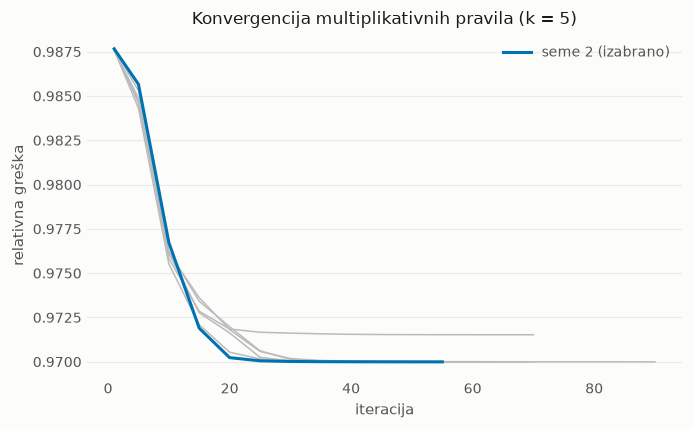

In [11]:
import matplotlib.pyplot as plt

# paleta za grafike
PLAVA = "#0072B2"
SIVA = "#BBBBBB"
CRTANJE = "#1A1A1A"
DRUGA_BOJA = "#555555"
POVRSINA = "#FCFCFB"
MREZA = "#EAEAEA"

fig, ax = plt.subplots(figsize=(6.4, 4.0), dpi=110, facecolor=POVRSINA)
ax.set_facecolor(POVRSINA)

for seme, _, _, ists in pokretanja:
    iteracije = [it for it, _ in ists]
    greske = [g for _, g in ists]
    if seme == NAJBOLJE_SEME:
        ax.plot(iteracije, greske, color=PLAVA, lw=2.0, zorder=3,
                label=f"seme {seme} (izabrano)")
    else:
        ax.plot(iteracije, greske, color=SIVA, lw=1.0, zorder=2)

ax.set_xlabel("iteracija", color=DRUGA_BOJA, fontsize=10)
ax.set_ylabel("relativna greška", color=DRUGA_BOJA, fontsize=10)
ax.set_title(f"Konvergencija multiplikativnih pravila (k = {BROJ_TEMA})",
             color=CRTANJE, fontsize=11)
ax.legend(frameon=False, fontsize=9, labelcolor=DRUGA_BOJA)

ax.grid(axis="y", color=MREZA, lw=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0, colors=DRUGA_BOJA, labelsize=9)

plt.tight_layout()
plt.show()

Sve krive padnu sa 0,988 na oko 0,970 za manje od 30 iteracija, a zaustavljanje po toleranciji se
dogodi između 55. i 90. iteracije. Jedna kriva se odvoji i stane na 0,9715, to je seme 0.

`uskladi_teme(W)`: svaki dokument dodeli najjačoj temi, $\hat{t}(d) = \arg\max_j W_{d,j}$, pa
teme upari sa kategorijama. Ako je $C$ matrica konfuzije, gde je $C_{i,j}$ broj dokumenata iz
kategorije $i$ dodeljenih temi $j$, traži se permutacija koja maksimizuje broj pogodaka

$$\sigma^{\star} = \arg\max_{\sigma \in S_k} \sum_{j=1}^{k} C_{\sigma(j),\, j}$$

To je problem dodele i rešava se Hungarian algoritmom, u kodu `linear_sum_assignment` nad $-C$
jer ta funkcija minimizuje. Grafik pokazuje koliko izbor semena menja tačnost.

In [12]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

klase = kategorije_lista
y_stvarno = np.array([klase.index(k) for k in kategorije])


def uskladi_teme(W_mat, y=y_stvarno, br_klasa=len(klase)):
    pred = W_mat.argmax(axis=1)
    C = confusion_matrix(y, pred, labels=list(range(br_klasa)))
    red, kol = linear_sum_assignment(-C)          # maksimizujemo dijagonalu
    mapa = dict(zip(kol, red))
    return np.array([mapa[p] for p in pred]), mapa

rezultati_seed = []
for seme, Ws, Hs, ists in pokretanja:
    pred_s, _ = uskladi_teme(Ws)
    rezultati_seed.append((seme, ists[-1][1], (pred_s == y_stvarno).mean()))

print(f"{'seme':>6} {'rel. greška':>13} {'tačnost':>10}")
print("-" * 45)
for seme, greska, tacnost_s in rezultati_seed:
    oznaka = "  <- izabrano" if seme == NAJBOLJE_SEME else ""
    print(f"{seme:>6} {greska:>13.5f} {tacnost_s:>9.1%}{oznaka}")

najgori = min(rezultati_seed, key=lambda r: r[2])
najbolji_po_tacnosti = max(rezultati_seed, key=lambda r: r[2])
print(f"\nRaspon tačnosti: od {najgori[2]:.1%} (seme {najgori[0]}) "
      f"do {najbolji_po_tacnosti[2]:.1%} (seme {najbolji_po_tacnosti[0]})")
print(f"Raspon greške:   od {min(r[1] for r in rezultati_seed):.5f} "
      f"do {max(r[1] for r in rezultati_seed):.5f}")


  seme   rel. greška    tačnost
---------------------------------------------
     0       0.97153     68.4%
     1       0.97000     93.2%
     2       0.97000     93.3%  <- izabrano
     3       0.97000     93.6%
    42       0.97000     93.4%
   123       0.97000     93.5%

Raspon tačnosti: od 68.4% (seme 0) do 93.6% (seme 3)
Raspon greške:   od 0.97000 do 0.97153


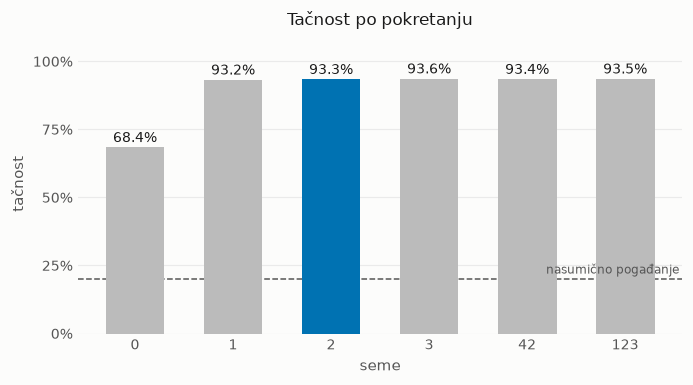

In [13]:
semena = [str(s) for s, _, _ in rezultati_seed]
tacnosti = [t for _, _, t in rezultati_seed]
boje = [PLAVA if s == NAJBOLJE_SEME else SIVA for s, _, _ in rezultati_seed]

fig, ax = plt.subplots(figsize=(6.4, 3.6), dpi=110, facecolor=POVRSINA)
ax.set_facecolor(POVRSINA)

stubovi = ax.bar(semena, tacnosti, width=0.6, color=boje, zorder=3)
for stub, t in zip(stubovi, tacnosti):
    ax.text(stub.get_x() + stub.get_width() / 2, t + 0.02, f"{t:.1%}",
            ha="center", fontsize=9, color=CRTANJE)

ax.axhline(1 / len(klase), color=DRUGA_BOJA, ls="--", lw=1.0, zorder=2)
ax.text(len(semena) - 0.45, 1 / len(klase) + 0.02, "nasumično pogađanje",
        ha="right", fontsize=8, color=DRUGA_BOJA)

ax.set_ylim(0, 1.1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("seme", color=DRUGA_BOJA, fontsize=10)
ax.set_ylabel("tačnost", color=DRUGA_BOJA, fontsize=10)
ax.set_title("Tačnost po pokretanju", color=CRTANJE, fontsize=11)

ax.grid(axis="y", color=MREZA, lw=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0, colors=DRUGA_BOJA, labelsize=9)

plt.tight_layout()
plt.show()

Seme 0 se po grešci razlikuje tek u trećoj decimali, a po tačnosti zaostaje 25 procentnih poena.
Multiplikativna pravila garantuju samo lokalni minimum, pa je pokretanje iz više početnih tačaka
neophodno.

### 6.1 Da li seme 0 izlazi iz lošijeg minimuma

Zaustavljanje po uslovu $|e_{i-1} - e_i| < \mathrm{tol}$ moglo bi da prekine pokretanje pre nego
što se ono zaista smiri. Zato seme 0 puštamo ponovo sa `tol=0`, čime uslov nikada nije ispunjen,
pa se odradi svih `max_iter` iteracija.

In [14]:
SEME_LOSE = 0

for seme, Ws, Hs, ists in pokretanja:
    if seme == SEME_LOSE:
        W_rano, ist_rano = Ws, ists
    if seme == NAJBOLJE_SEME:
        ist_izabrano = ists

for s, g, t in rezultati_seed:
    if s == NAJBOLJE_SEME:
        tac_izabrano = t

pred_rano, _ = uskladi_teme(W_rano)
redovi = [("zaustavljeno po toleranciji", ist_rano[-1][0], ist_rano[-1][1],
           (pred_rano == y_stvarno).mean())]

for granica in (400, 2000):
    Wd, Hd, istd = nmf_mu(V, BROJ_TEMA, max_iter=granica, seed=SEME_LOSE,
                          tol=0.0, verbose=False)
    pred_d, _ = uskladi_teme(Wd)
    redovi.append((f"{granica} iteracija, tol iskljucen", istd[-1][0], istd[-1][1],
                   (pred_d == y_stvarno).mean()))
    W_dugo, pred_dugo = Wd, pred_d

print(f"{'varijanta':<30} {'iter':>6} {'rel. greška':>14} {'tačnost':>10}")
print("-" * 64)
for naziv, it, greska, tac in redovi:
    print(f"{naziv:<30} {it:>6} {greska:>14.7f} {tac:>9.1%}")
print("-" * 64)
print(f"{f'seme {NAJBOLJE_SEME} (izabrano)':<30} {ist_izabrano[-1][0]:>6} "
      f"{ist_izabrano[-1][1]:>14.7f} {tac_izabrano:>9.1%}")

print()
print("Broj dokumenata po temama (argmax po vrstama matrice W):")
print(f"   seme {SEME_LOSE} do kraja:  {np.bincount(W_dugo.argmax(axis=1), minlength=BROJ_TEMA)}")
print(f"   seme {NAJBOLJE_SEME}:            {np.bincount(W.argmax(axis=1), minlength=BROJ_TEMA)}")

C0 = confusion_matrix(y_stvarno, pred_dugo, labels=list(range(len(klase))))
print()
print(f"Matrica konfuzije za seme {SEME_LOSE} posle {redovi[-1][1]} iteracija:")
print(f"{'':<15}" + "".join(f"{k[:9]:>11}" for k in klase))
for i, k in enumerate(klase):
    print(f"{k:<15}" + "".join(f"{v:>11}" for v in C0[i]))

varijanta                        iter    rel. greška    tačnost
----------------------------------------------------------------
zaustavljeno po toleranciji        70      0.9715255     68.4%
400 iteracija, tol iskljucen      400      0.9715218     68.2%
2000 iteracija, tol iskljucen    2000      0.9715218     68.2%
----------------------------------------------------------------
seme 2 (izabrano)                  55      0.9699955     93.3%

Broj dokumenata po temama (argmax po vrstama matrice W):
   seme 0 do kraja:  [279 306 757 516 367]
   seme 2:            [436 522 377 349 541]

Matrica konfuzije za seme 0 posle 2000 iteracija:
                  business  entertain   politics      sport       tech
business               290        192          9          1         18
entertainment            4         15          1          9        357
politics                11         30        356          9         11
sport                    0         25          0        486          0
tec

Greška se posle 400. iteracije ne pomeri ni na sedmoj decimali, a tačnost čak neznatno padne.
Zaustavljanje po toleranciji dakle nije bilo krivo, ono je odseklo oko $4 \cdot 10^{-6}$ greške.
Seme 0 zaista jeste u lokalnom minimumu i iz njega ne izlazi ni posle 2000 iteracija.

Matrica konfuzije pokazuje šta se desilo. Tema uparena sa kategorijom tech skupila je 757
dokumenata, i to skoro ceo entertainment (357) i skoro ceo tech (371). Zauzvrat se business raspao
na dve teme, 290 dokumenata u jednoj i 192 u drugoj, pa je ta druga uparena sa entertainment iako
u njoj entertainment gotovo i nema.

Multiplikativna pravila tako nešto ne mogu da poprave. Matrice `W` i `H` se u svakom koraku množe
nenegativnim količnikom, pa koordinata koja jednom padne na nulu tu i ostaje, i dve slivene teme
nemaju čime da se razdvoje. Rešenje nije više iteracija nego druga početna tačka, zato se i uzima
najbolje od šest pokretanja.

## 7. Otkrivene teme

`top_tokeni_teme(H, i)`: tokeni sa najvećom težinom u temi `i`, to jest sortiran red matrice `H`.

In [15]:
def top_tokeni_teme(H_mat, tema, koliko=12):
    poredak = np.argsort(H_mat[tema])[::-1]
    izlaz = []
    for j in poredak:
        t = recnik[j]
        izlaz.append(t)
        if len(izlaz) == koliko:
            break
    return izlaz


print("=" * 78)
print(f"OTKRIVENE TEME (NMF, k={BROJ_TEMA}, seme {NAJBOLJE_SEME})".center(78))
print("=" * 78)
for i in range(BROJ_TEMA):
    print(f"\nTEMA {i + 1}")
    print(f"  sve:      {', '.join(top_tokeni_teme(H, i, 12))}")

                      OTKRIVENE TEME (NMF, k=5, seme 2)                       

TEMA 1
  sve:      mobile, people, music, technology, phone, digital, can, users, broadband, net, phones, software

TEMA 2
  sve:      us, growth, economy, bank, oil, sales, economic, market, prices, china, company, dollar

TEMA 3
  sve:      labour, election, blair, brown, party, government, howard, minister, prime, tax, prime minister, chancellor

TEMA 4
  sve:      film, best, awards, award, actor, oscar, festival, films, actress, won, director, star

TEMA 5
  sve:      england, game, win, wales, ireland, cup, team, play, side, first, players, match


Pet tema odgovara pet kategorija korpusa, a model nijednu oznaku nije video. Među tokenima sa
najvećom težinom ima i bigrama, na primer `prime minister` u temi politike.

## 8. Evaluacija

`pred`: teme uparene sa kategorijama. `tacnost`, `nmi` i `ari`: mere slaganja sa stvarnom podelom.

Tačnost zavisi od uparivanja, pa se uz nju gledaju i dve mere kojima numeracija tema nije važna.
Normalizovana uzajamna informacija podela $U$ i $T$ je

$$\mathrm{NMI}(U, T) = \frac{2\, I(U; T)}{H(U) + H(T)}$$

gde je $I$ uzajamna informacija, a $H$ entropija. Prilagođeni Randov indeks popravlja Randov
indeks za slaganje koje bi se dobilo slučajno,

$$\mathrm{ARI} = \frac{\mathrm{RI} - \mathbb{E}[\mathrm{RI}]}{\max(\mathrm{RI}) - \mathbb{E}[\mathrm{RI}]}$$

pa je oko $0$ za nasumičnu podelu, a $1$ za savršeno poklapanje.

In [16]:
from sklearn.metrics import (normalized_mutual_info_score, adjusted_rand_score,
                             classification_report)

pred, mapa_tema = uskladi_teme(W)
sirove_teme = W.argmax(axis=1)

tacnost = (pred == y_stvarno).mean()
nmi = normalized_mutual_info_score(y_stvarno, sirove_teme)
ari = adjusted_rand_score(y_stvarno, sirove_teme)

print(f"Tačnost (posle Hungarian uparivanja): {tacnost:.2%}")
print(f"NMI:                                  {nmi:.4f}")
print(f"ARI:                                  {ari:.4f}")
print(f"Nasumično pogađanje:                  {1 / len(klase):.2%}\n")

print("Uparivanje tema sa kategorijama:")
for tema, kat in sorted(mapa_tema.items()):
    print(f"   TEMA {tema + 1}  ->  {klase[kat]:<15} "
          f"[{', '.join(top_tokeni_teme(H, tema, 5))}]")

print("\n" + classification_report(y_stvarno, pred, target_names=klase, digits=3))

Tačnost (posle Hungarian uparivanja): 93.35%
NMI:                                  0.8146
ARI:                                  0.8455
Nasumično pogađanje:                  20.00%

Uparivanje tema sa kategorijama:


   TEMA 1  ->  tech            [mobile, people, music, technology, phone]
   TEMA 2  ->  business        [us, growth, economy, bank, oil]
   TEMA 3  ->  politics        [labour, election, blair, brown, party]
   TEMA 4  ->  entertainment   [film, best, awards, award, actor]
   TEMA 5  ->  sport           [england, game, win, wales, ireland]

               precision    recall  f1-score   support

     business      0.927     0.949     0.938       510
entertainment      0.974     0.881     0.925       386
     politics      0.979     0.885     0.929       417
        sport      0.939     0.994     0.966       511
         tech      0.862     0.938     0.898       401

     accuracy                          0.933      2225
    macro avg      0.936     0.929     0.931      2225
 weighted avg      0.936     0.933     0.933      2225



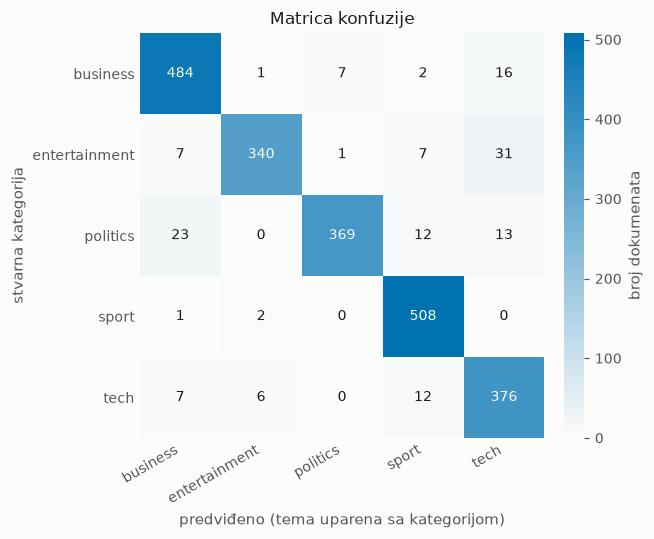

In [17]:
from matplotlib.colors import LinearSegmentedColormap

PLAVA_RAMPA = LinearSegmentedColormap.from_list("plava_rampa", [POVRSINA, PLAVA])

C = confusion_matrix(y_stvarno, pred, labels=list(range(len(klase))))

fig, ax = plt.subplots(figsize=(6.0, 5.0), dpi=110, facecolor=POVRSINA)
ax.set_facecolor(POVRSINA)
slika = ax.imshow(C, cmap=PLAVA_RAMPA, vmin=0, vmax=C.max())

ax.set_xticks(range(len(klase)), klase, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(klase)), klase, fontsize=9)
ax.set_xlabel("predviđeno (tema uparena sa kategorijom)", color=DRUGA_BOJA, fontsize=10)
ax.set_ylabel("stvarna kategorija", color=DRUGA_BOJA, fontsize=10)
ax.set_title("Matrica konfuzije", color=CRTANJE, fontsize=11)

prag = C.max() * 0.55
for i in range(len(klase)):
    for j in range(len(klase)):
        ax.text(j, i, C[i, j], ha="center", va="center", fontsize=9,
                color=POVRSINA if C[i, j] > prag else CRTANJE)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0, colors=DRUGA_BOJA)

traka = fig.colorbar(slika, ax=ax, fraction=0.045, pad=0.04)
traka.set_label("broj dokumenata", color=DRUGA_BOJA, fontsize=10)
traka.ax.tick_params(colors=DRUGA_BOJA, labelsize=9)
traka.outline.set_visible(False)

plt.tight_layout()
plt.show()

`C`: matrica konfuzije. Dijagonala je dominantna, a greške su najviše između kategorija
entertainment i tech, i između politics i business.

### 8.1 Poređenje sa sklearn-om

In [18]:
from sklearn.decomposition import NMF as SklearnNMF

model_sk = SklearnNMF(n_components=BROJ_TEMA, init="random", max_iter=400,
                      random_state=NAJBOLJE_SEME)
W_sk = model_sk.fit_transform(V)

norma_V = math.sqrt(V.multiply(V).sum())
rel_sk = model_sk.reconstruction_err_ / norma_V
pred_sk, _ = uskladi_teme(W_sk)
tacnost_sk = (pred_sk == y_stvarno).mean()
nmi_sk = normalized_mutual_info_score(y_stvarno, W_sk.argmax(axis=1))

print(f"{'implementacija':<28} {'rel. greška':>12} {'tačnost':>9} {'NMI':>7}")
print("-" * 68)
print(f"{'naša (MU, NumPy)':<28} {istorija[-1][1]:>12.5f} {tacnost:>8.1%} "
      f"{nmi:>7.3f}")
print(f"{'sklearn (CD)':<28} {rel_sk:>12.5f} {tacnost_sk:>8.1%} "
      f"{nmi_sk:>7.3f}")
print("-" * 68)

poklapanje = (pred == pred_sk).mean()
print(f"\nDve implementacije dodeljuju isti dokument istoj temi u {poklapanje:.1%} slučajeva.")

implementacija                rel. greška   tačnost     NMI
--------------------------------------------------------------------
naša (MU, NumPy)                  0.97000    93.3%   0.815
sklearn (CD)                      0.96999    92.4%   0.797
--------------------------------------------------------------------

Dve implementacije dodeljuju isti dokument istoj temi u 97.7% slučajeva.


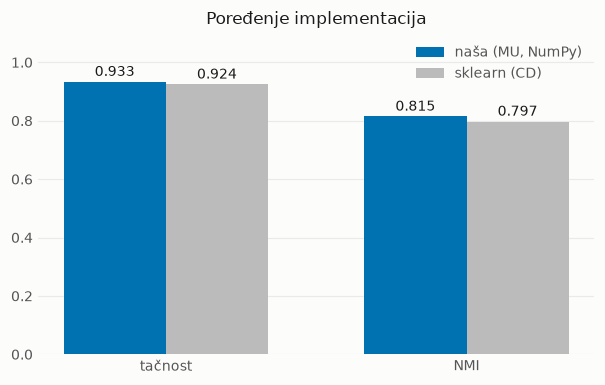

In [19]:
mere = ["tačnost", "NMI"]
nase = [tacnost, nmi]
sklearnove = [tacnost_sk, nmi_sk]

x = np.arange(len(mere))
sirina = 0.34

fig, ax = plt.subplots(figsize=(5.6, 3.6), dpi=110, facecolor=POVRSINA)
ax.set_facecolor(POVRSINA)

levi = ax.bar(x - sirina / 2, nase, sirina, color=PLAVA, zorder=3,
              label="naša (MU, NumPy)")
desni = ax.bar(x + sirina / 2, sklearnove, sirina, color=SIVA, zorder=3,
               label="sklearn (CD)")

for grupa in (levi, desni):
    for stub in grupa:
        v = stub.get_height()
        ax.text(stub.get_x() + stub.get_width() / 2, v + 0.02, f"{v:.3f}",
                ha="center", fontsize=9, color=CRTANJE)

ax.set_xticks(x, mere, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title("Poređenje implementacija", color=CRTANJE, fontsize=11)
ax.legend(frameon=False, fontsize=9, labelcolor=DRUGA_BOJA)

ax.grid(axis="y", color=MREZA, lw=0.8)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0, colors=DRUGA_BOJA, labelsize=9)

plt.tight_layout()
plt.show()

Greška i tačnost su skoro iste kao kod naše implementacije. Sklearn je brži jer koordinatnom
spustu treba manje prolaza kroz podatke.

## 9. Semantička pretraga

Kolona $H_{:,t}$ je vektor tokena $t$ u prostoru tema. Bliskost dva tokena merimo kosinusom ugla
između njihovih vektora,

$$\cos(t, u) = \frac{\langle H_{:,t},\, H_{:,u} \rangle}{\|H_{:,t}\|_2\, \|H_{:,u}\|_2}$$

pa se posle normalizacije vektora na jediničnu dužinu kosinus svodi na običan skalarni proizvod.

`slicne_reci(upit)`: kosinusna sličnost nad `E_norm`, iz posebnog modela sa $k = 40$, uz kandidate
sa $\mathrm{df} \ge 20$.

In [20]:
BROJ_TEMA_SEM = 40
SEMENA_SEM = [0, 1, 2]

t0 = time.time()

W_sem, H_sem, ist_sem = None, None, None
for seme in SEMENA_SEM:
    Wc, Hc, istc = nmf_mu(V, BROJ_TEMA_SEM, max_iter=300, seed=seme, verbose=False)
    print(f"   seme {seme}: relativna greška {istc[-1][1]:.5f}")
    if ist_sem is None or istc[-1][1] < ist_sem[-1][1]:
        W_sem, H_sem, ist_sem = Wc, Hc, istc

print(f"Gotovo za {time.time() - t0:.1f} s, izabrana greška: {ist_sem[-1][1]:.5f}")

# vektor reci je kolona iz H normalizovana na dužinu 1
E = H_sem.T                                              # M x k
E_norm = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-12)

MIN_DF_PRETRAGA = 20
df_niz = np.array([df_broj[t] for t in recnik])
maska_kandidata = df_niz >= MIN_DF_PRETRAGA
print(f"Kandidata za pretragu: {maska_kandidata.sum():,} od {M:,} tokena "
      f"(df >= {MIN_DF_PRETRAGA})")


def slicne_reci(upit, koliko=8):
    '''najbliži tokeni zadatom upitu, kao lista (token, sličnost)'''
    upit = upit.lower().strip()
    if upit not in token_u_indeks:
        return None
    j = token_u_indeks[upit]
    slicnosti = E_norm @ E_norm[j]           # vektori su normalizovani pa je kosinus samo skalarni proizvod
    slicnosti[~maska_kandidata] = -1.0
    slicnosti[j] = -1.0                      # sam upit ne broji
    najbolji = np.argpartition(-slicnosti, koliko)[:koliko]
    najbolji = najbolji[np.argsort(-slicnosti[najbolji])]
    return [(recnik[i], float(slicnosti[i])) for i in najbolji]


print("\nSemantička pretraga je spremna.")

   seme 0: relativna greška 0.91659


   seme 1: relativna greška 0.91676


   seme 2: relativna greška 0.91683
Gotovo za 84.7 s, izabrana greška: 0.91659


Kandidata za pretragu: 3,494 od 12,798 tokena (df >= 20)

Semantička pretraga je spremna.


In [21]:
upiti = ["mobile phone", "prime minister", "interest rates", "film",
         "chelsea", "software", "oil prices", "album"]

for upit in upiti:
    rezultat = slicne_reci(upit, koliko=8)
    print(f"\n'{upit}'")
    if rezultat is None:
        print("   [nije u rečniku]")
        continue
    for token, s in rezultat:
        print(f"   {s:.3f}  {token}")


'mobile phone'
   0.999  mobile
   0.999  phones
   0.999  mobile phones
   0.997  handset
   0.995  handsets
   0.994  mobiles
   0.993  messaging
   0.973  phone

'prime minister'
   1.000  prime
   0.990  third term
   0.988  allies
   0.982  blair
   0.975  brown
   0.968  minister
   0.968  suspicion
   0.957  journalist

'interest rates'
   0.996  rates
   0.989  interest rate
   0.982  inflation
   0.979  manufacturing
   0.977  chief economist
   0.972  optimism
   0.955  interest
   0.950  rate

'film'
   0.996  directed
   0.983  starring
   0.976  girl
   0.971  documentary
   0.971  festival
   0.970  film festival
   0.970  berlin
   0.969  cinema

'chelsea'
   0.992  mourinho
   0.992  barcelona
   0.986  bridge
   0.972  leg
   0.962  jose
   0.935  cole
   0.925  cup final
   0.917  blues

'software'
   0.971  programs
   0.966  operating system
   0.961  windows
   0.958  program
   0.954  anti virus
   0.948  microsoft
   0.946  pcs
   0.930  malicious

'oil prices'


Susedi nisu samo morfološke varijante iste reči. Uz `chelsea` stoje `mourinho` i `barcelona`, uz
`album` stoje `elvis` i `hip hop`. Kod `oil prices` se vidi granica metode, model vrati opšti
ekonomski kontekst jer ni sa k = 40 nema dovoljno finu podelu za tako usku temu.

## 10. Zaključak

Sopstvena TF-IDF matrica poklapa se sa `sklearn`-ovom do mašinske preciznosti, a sopstvena NMF
daje istu relativnu grešku kao `sklearn` (0,970) uz nešto veću tačnost, 93,3% naspram 92,4%. Dve
implementacije svrstaju isti dokument u istu temu u 97,7% slučajeva.

Pet tema koje NMF izdvoji, bez ijedne viđene oznake, odgovaraju pet kategorija korpusa. Tačnost
posle Hungarian uparivanja je 93,35%, NMI 0,815 i ARI 0,846, dok nasumično pogađanje daje 20%.
Greške su skoro sve između entertainment i tech i između politics i business.

Bigrami su se pokazali kao koristan dodatak rečniku. Fraze `prime minister`, `interest rate` i
`operating system` ulaze i među tokene sa najvećom težinom u temama i među rezultate semantičke
pretrage.

Najveće ograničenje je osetljivost na početnu tačku. Multiplikativna pravila konvergiraju u lokalni
minimum, pa jedno od šest pokretanja završi na 68,4% tačnosti iako mu se greška rekonstrukcije
razlikuje tek u trećoj decimali. U sekciji 6.1 je provereno da to nije posledica prevremenog
zaustavljanja, jer se ni sa isključenom tolerancijom kroz 2000 iteracija ništa ne menja. Zato se za
dalji rad uzima najbolje od šest pokretanja.

## Literatura

- D. D. Lee, H. S. Seung, *Learning the parts of objects by non-negative matrix factorization*,
  Nature 401 (1999), 788-791.
- D. D. Lee, H. S. Seung, *Algorithms for Non-negative Matrix Factorization*, NIPS 13 (2001).
  Odatle su multiplikativna pravila koja su ovde implementirana.
- W. Xu, X. Liu, Y. Gong, *Document Clustering Based On Non-negative Matrix Factorization*,
  SIGIR 2003.
- D. Greene, P. Cunningham, *Practical Solutions to the Problem of Diagonal Dominance in Kernel
  Document Clustering*, ICML 2006. Rad uz koji je objavljen BBC korpus.
- Dokumentacija `scikit-learn`-a:
  [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html),
  [NMF](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html).